In [1]:
#thanks to Andy (https://github.com/andymcdgeo/Andys_YouTube_Notebooks/commits?author=andymcdgeo) for the code oon reading and using a .las file

In [2]:
pip install lasio

Note: you may need to restart the kernel to use updated packages.


In [3]:
#can also install what seems like a similar package through conda --> conda install ziebel::lasio

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import lasio

In [91]:
caliper = lasio.read("Parish886189_CALIPER_4-22-2025.las")

In [92]:
caliper.sections.keys()

dict_keys(['Version', 'Well', 'Curves', 'Parameter', 'Other'])

In [93]:
caliper.sections['Version']

[HeaderItem(mnemonic="VERS", unit="", value="2.0", descr="CWLS LOG ASCII STANDA"),
 HeaderItem(mnemonic="WRAP", unit="", value="NO", descr="ONE LINE PER DEPTH STE")]

In [94]:
for item in caliper.sections['Well']:
    print(f"{item.descr} ({item.mnemonic}): \t\t {item.value}")

FIRST INDEX VALUE (STRT): 		 4.2296
LAST INDEX VALUE (STOP): 		 269.254
STEP (STEP): 		 0.0
NULL VALUE (NULL): 		 -99999
 (COMP): 		 
WELL (WELL): 		 CARLTON (DARCY TW)
 (FLD): 		 
 (LOC): 		 
 (SRVC): 		 
CTRY (CTRY): 		 USA
STAT (STAT): 		 MINNESOTA
CNTY (CNTY): 		 RICE
DATE (DATE): 		 04/22/2025
API (API): 		 886189


In [95]:
for curve in caliper.curves:
    print(curve.mnemonic)

DEPT
CALIPER-IN
TIME
TCPU
MOTOR
CALIPER-CM
OPEN
CLOSE
ARM
SPEED
TOOLPOWERVOLTAGE
TOOLPOWERCURRENT


In [96]:
for count, curve in enumerate(caliper.curves):
    print(f"Curve: {curve.mnemonic}, \t Units: {curve.unit}, \t Description: {curve.descr}")
print(f"There are a total of: {count+1} curves present within this file")

Curve: DEPT, 	 Units: FT, 	 Description: DEPTH
Curve: CALIPER-IN, 	 Units: IN, 	 Description: Caliper-In
Curve: TIME, 	 Units: SEC, 	 Description: Time
Curve: TCPU, 	 Units: 'C, 	 Description: TCPU
Curve: MOTOR, 	 Units: , 	 Description: Motor
Curve: CALIPER-CM, 	 Units: CM, 	 Description: Caliper-Cm
Curve: OPEN, 	 Units: , 	 Description: Open
Curve: CLOSE, 	 Units: , 	 Description: Close
Curve: ARM, 	 Units: , 	 Description: Arm
Curve: SPEED, 	 Units: FT/MIN, 	 Description: Speed
Curve: TOOLPOWERVOLTAGE, 	 Units: V, 	 Description: ToolPowerVoltage
Curve: TOOLPOWERCURRENT, 	 Units: MA, 	 Description: ToolPowerCurrent
There are a total of: 12 curves present within this file


In [97]:
callog = caliper.df()

In [98]:
callog

,CALIPER-IN,TIME,TCPU,MOTOR,CALIPER-CM,OPEN,CLOSE,ARM,SPEED,TOOLPOWERVOLTAGE,TOOLPOWERCURRENT
DEPT,,,,,,,,,,,
4.2296,6.24631,NaN,NaN,NaN,15.7852,NaN,NaN,NaN,NaN,NaN,NaN
4.3936,6.24631,NaN,NaN,NaN,15.7852,NaN,NaN,NaN,NaN,NaN,NaN
4.5576,6.24631,NaN,NaN,NaN,15.7852,NaN,NaN,NaN,NaN,NaN,NaN
4.7216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.8856,6.24631,0.368,20.1325,128.0,15.7852,0.0,1.0,-1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
268.5980,NaN,1.068,20.7842,128.0,NaN,0.0,1.0,-1.0,19.40930,118.000,15.1351
268.7620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.35700,118.787,15.1351
268.9260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.06490,119.000,15.1351


In [99]:
callog.describe()

,CALIPER-IN,TIME,TCPU,MOTOR,CALIPER-CM,OPEN,CLOSE,ARM,SPEED,TOOLPOWERVOLTAGE,TOOLPOWERCURRENT
count,1402.000000,1402.000000,1402.000000,1402.0,1402.000000,1402.0,1402.0,1402.0,1609.000000,1609.000000,1609.000000
mean,6.278404,0.549965,20.280432,128.0,15.865432,0.0,1.0,-1.0,18.023727,118.396506,19.508299
std,0.312311,0.042045,0.185920,0.0,0.780328,0.0,0.0,0.0,1.933261,11.446244,4.403006
min,6.060730,0.334002,20.132500,128.0,15.325400,0.0,1.0,-1.0,8.851610,0.000000,0.000000
25%,6.094470,0.553003,20.132500,128.0,15.409000,0.0,1.0,-1.0,17.552500,119.000000,16.216200
50%,6.232045,0.557247,20.142100,128.0,15.749900,0.0,1.0,-1.0,17.634500,119.695000,19.459500
75%,6.341000,0.560932,20.349800,128.0,16.019875,0.0,1.0,-1.0,17.798600,120.139000,23.783800
max,10.285900,1.068000,20.784200,128.0,26.122600,0.0,1.0,-1.0,29.363500,121.000000,25.945900


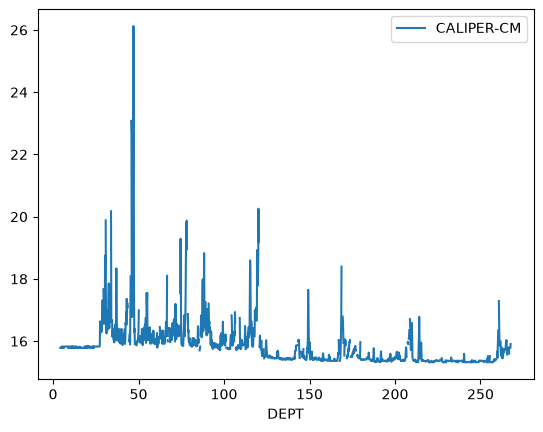

In [100]:
callog.plot(y = "CALIPER-CM");

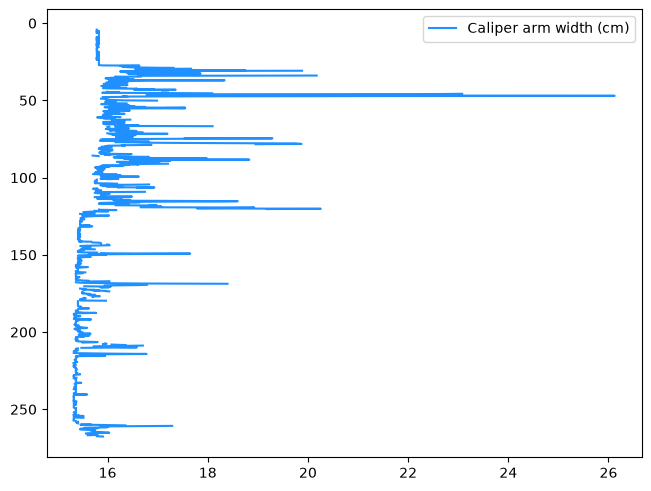

In [101]:
fig, ax = plt.subplots(layout = 'constrained')
plt.plot(callog.loc[:, "CALIPER-CM"], callog.index, label = "Caliper arm width (cm)", color = "dodgerblue")
ax.invert_yaxis()


plt.legend()

plt.show()

Reading the Parish Data from the second of May, June, and July using Jasper's .csv file

In [102]:
dts = pd.read_csv("folded1.csv")
dts = dts.set_index("LAF") # sets index to length along fiber (m) so that we can look at temperature along the well at the same scale as the caliper log.
dts = dts[dts.leg != "up"] # gets rid of the second half of the cable where it is folded in on itself.
dts

,ST,AST,REV-ST,REV-AST,TMP,start_time,depth_m,datetime,label,leg
LAF,,,,,,,,,,
0.101,3504.88,3436.54,2851.77,2832.12,22.543,2026-05-02T11:59:36.502Z,0.101,2026-05-02 11:59:36.502,2026-05-02 11:59,down
0.355,3295.38,3183.73,3055.83,2968.48,19.239,2026-05-02T11:59:36.502Z,0.355,2026-05-02 11:59:36.502,2026-05-02 11:59,down
0.609,3250.22,3094.20,3237.66,3072.99,15.919,2026-05-02T11:59:36.502Z,0.609,2026-05-02 11:59:36.502,2026-05-02 11:59,down
0.864,3252.57,3059.49,3308.69,3102.10,13.831,2026-05-02T11:59:36.502Z,0.864,2026-05-02 11:59:36.502,2026-05-02 11:59,down
1.118,3250.99,3054.07,3315.11,3088.22,13.175,2026-05-02T11:59:36.502Z,1.118,2026-05-02 11:59:36.502,2026-05-02 11:59,down
...,...,...,...,...,...,...,...,...,...,...
82.462,3267.92,2870.44,3787.24,3328.92,10.911,2026-07-02T12:00:27.439Z,82.462,2026-07-02 12:00:27.439,2026-07-02 12:00,down
82.716,3266.88,2869.93,3787.89,3330.11,10.939,2026-07-02T12:00:27.439Z,82.716,2026-07-02 12:00:27.439,2026-07-02 12:00,down
82.970,3239.74,2851.20,3786.23,3333.24,11.204,2026-07-02T12:00:27.439Z,82.970,2026-07-02 12:00:27.439,2026-07-02 12:00,down


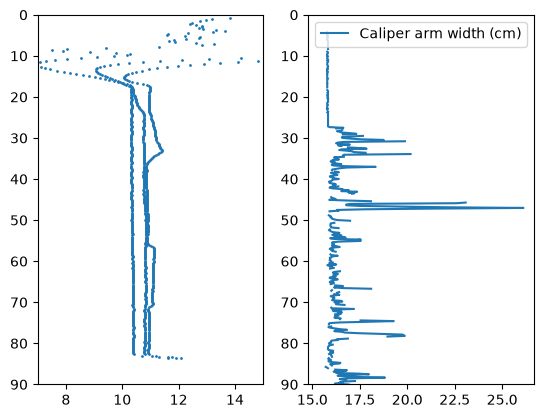

In [103]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(dts.loc[:, "TMP"], dts.index, s = 1, label = "temperature (C)")
ax2.plot(callog.loc[:, "CALIPER-CM"], callog.index, label = "Caliper arm width (cm)")
# ax1.invert_yaxis()
# ax1.invert_yaxis()
ax1.set_ylim(90, 0)
ax1.set_xlim(7, 15)
ax2.set_ylim(90, 0)

plt.legend()
plt.show();

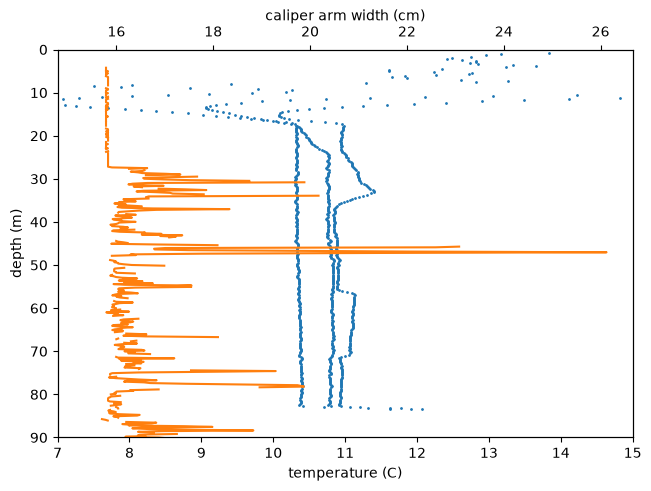

In [104]:
fig, ax1 = plt.subplots(layout = 'constrained')
temp = ax1.scatter(dts.loc[:, "TMP"], dts.index, label = "temperature (C)", s = 1, color = "tab:blue")

ax2 = ax1.twiny() 
width = ax2.plot(callog.loc[:, "CALIPER-CM"], callog.index, label = "Caliper arm width (cm)", color = "tab:orange")
ax1.set_ylim(90, 0)
ax1.set_xlim(7, 15)
ax2.set_ylim(90, 0)
# ax2.set_xlim(18, 22)

ax1.set_xlabel('temperature (C)')
ax1.set_ylabel('depth (m)')
ax2.set_xlabel('caliper arm width (cm)') 

# leg = temp + width
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)

plt.show();

Trying to parse the raw .xml files from the Parish House Silixa computer

In [105]:
import os
from dtscalibration import read_silixa_files

In [106]:
import dtscalibration
from dtscalibration.variance_stokes import variance_stokes_constant
import matplotlib.pyplot as plt

In [107]:
filepath = os.path.join("..", "..", "tests", "data", "single_ended")
ds = read_silixa_files(directory = r"C:\Users\HydroResearch\Documents\GitHub\summer_26\summer 2026", timezone_netcdf="UTC", file_ext="*.xml")

1 files were found, each representing a single timestep
6 recorded vars were found: LAF, ST, AST, REV-ST, REV-AST, TMP
Recorded at 1759 points along the cable
The measurement is double ended
Reading the data from disk


In [108]:
ds

<xarray.Dataset> Size: 85kB
Dimensions:                (x: 1759, time: 1)
Coordinates: (12/14)
  * x                      (x) float64 14kB -225.4 -225.1 -224.9 ... 221.3 221.5
  * time                   (time) datetime64[ns] 8B 2026-04-10T16:07:19.952000
    filename               (time) <U37 148B 'channel 1_UTC_20260410_155519.27...
    filename_tstamp        (time) int64 8B 2604101555
    timeFWstart            (time) datetime64[ns] 8B 2026-04-10T15:55:19.952000
    timeFWend              (time) datetime64[ns] 8B 2026-04-10T16:07:19.952000
    ...                     ...
    timeBWend              (time) datetime64[ns] 8B 2026-04-10T16:19:19.952000
    timeBW                 (time) datetime64[ns] 8B 2026-04-10T16:13:19.952000
    timestart              (time) datetime64[ns] 8B 2026-04-10T15:55:19.952000
    timeend                (time) datetime64[ns] 8B 2026-04-10T16:19:19.952000
    acquisitiontimeFW      (time) timedelta64[s] 8B 00:12:00
    acquisitiontimeBW      (time) timedelta64[s] 8B 00:12:00
Data variables: (12/14)
    st                     (x, time) float64 14kB -0.04776 -0.06474 ... -17.83
    ast                    (x, time) float64 14kB 0.009051 0.02057 ... -16.04
    rst                    (x, time) float64 14kB 0.006434 0.0888 ... 5.061e+03
    rast                   (x, time) float64 14kB 0.02168 0.04795 ... 4.189e+03
    tmp                    (x, time) float64 14kB -14.64 -81.94 ... 3.687 -3.514
    acquisitionTime        (time) float32 4B 720.7
    ...                     ...
    probe2Temperature      (time) float32 4B 839.1
    referenceProbeVoltage  (time) float32 4B 0.1054
    probe1Voltage          (time) float32 4B 0.5
    probe2Voltage          (time) float32 4B 0.5
    userAcquisitionTimeFW  (time) float32 4B 720.0
    userAcquisitionTimeBW  (time) float32 4B 720.0
Attributes: (12/366)
    uid:                                                                     ...
    nameWell:                                                                ...
    nameWellbore:                                                            ...
    name:                                                                    ...
    indexType:                                                               ...
    startIndex:uom:                                                          ...
    ...                                                                                                                                                    ...
    customData:UserConfiguration:ChannelConfiguration_3:FibreCheckConfigurati...
    customData:UserConfiguration:ChannelConfiguration_3:FibreCorrectionConfig...
    customData:UserConfiguration:ChannelConfiguration_3:FibreCorrectionConfig...
    isDoubleEnded:                                                           ...
    forwardMeasurementChannel:                                               ...
    backwardMeasurementChannel:                                              ...

In [109]:
temp = ds.tmp
temp

<xarray.DataArray 'tmp' (x: 1759, time: 1)> Size: 14kB
array([[-14.637],
       [-81.944],
       [-78.055],
       ...,
       [  6.123],
       [  3.687],
       [ -3.514]], shape=(1759, 1))
Coordinates: (12/14)
  * x                  (x) float64 14kB -225.4 -225.1 -224.9 ... 221.3 221.5
  * time               (time) datetime64[ns] 8B 2026-04-10T16:07:19.952000
    filename           (time) <U37 148B 'channel 1_UTC_20260410_155519.270.xml'
    filename_tstamp    (time) int64 8B 2604101555
    timeFWstart        (time) datetime64[ns] 8B 2026-04-10T15:55:19.952000
    timeFWend          (time) datetime64[ns] 8B 2026-04-10T16:07:19.952000
    ...                 ...
    timeBWend          (time) datetime64[ns] 8B 2026-04-10T16:19:19.952000
    timeBW             (time) datetime64[ns] 8B 2026-04-10T16:13:19.952000
    timestart          (time) datetime64[ns] 8B 2026-04-10T15:55:19.952000
    timeend            (time) datetime64[ns] 8B 2026-04-10T16:19:19.952000
    acquisitiontimeFW  (time) timedelta64[s] 8B 00:12:00
    acquisitiontimeBW  (time) timedelta64[s] 8B 00:12:00
Attributes:
    name:         TEMP
    description:  Temperature calibrated by device
    units:        $^\circ$C

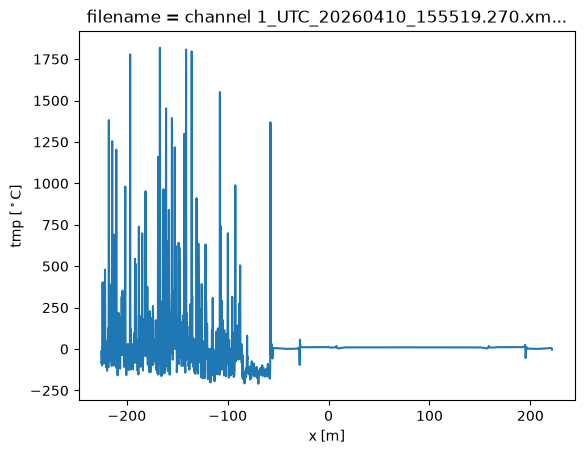

In [110]:

temp.plot();

''

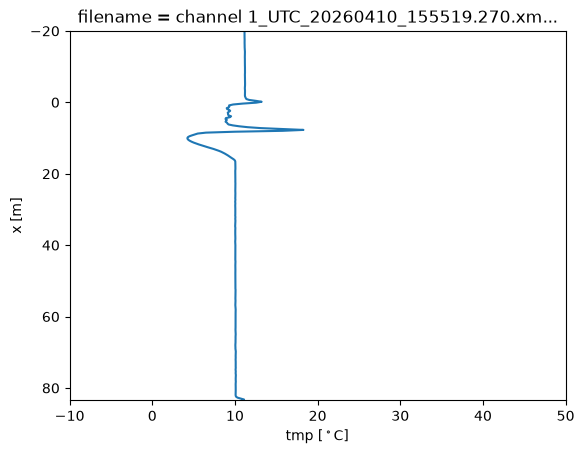

In [117]:
temp.plot(ylim = (83.5, -20), xlim = (-10, 50), y = "x")
;

plotting caliper and dts on top of each other? --> wont work until the dts has real depth assigned to it.

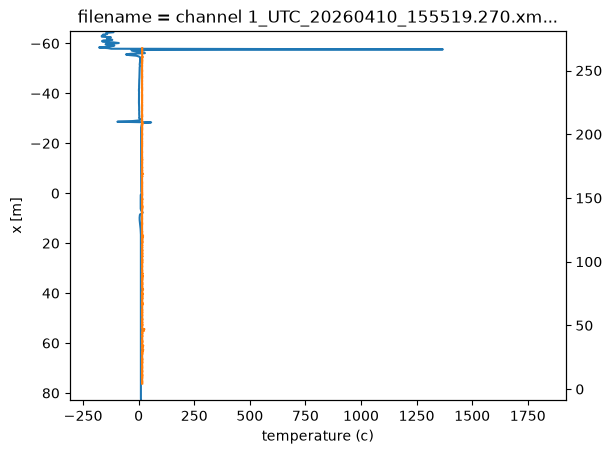

In [119]:
caliper = pd.callog
fig, ax1 = plt.subplots()
temp.plot(ax=ax1, ylim = (83, -65), y = "x", color = "tab:blue")
ax1.set_xlabel("temperature (c)")

ax2 = ax1.twinx() 
ax2.plot(callog.loc[:, "CALIPER-CM"], callog.index, label = "Caliper arm width (cm)", color = "tab:orange")
ax2.set_xlabel("caliper arm width (cm)")

plt.show()

In [17]:
# ds = ds.sel(x=slice(-225.374, 101))  # dismiss parts of the fiber that are not interesting
sections = {
    "probe1Temperature": [slice(839.194)],  # warm bath
    "probe2Temperature": [slice(839.061)],  # cold bath
}

In [18]:
st_var, resid = variance_stokes_constant(
    ds.dts.st, (-0.04776, -17.83), ds.dts.acquisitiontime_fw, reshape_residuals=True
)
ast_var, _ = variance_stokes_constant(
    ds.dts.ast, (0.009051, -16.04), ds.dts.acquisitiontime_fw, reshape_residuals=False
)

AssertionError: 

In [ ]:
resid.plot(figsize=(12, 4))

In [ ]:
ds.plot.scatter()

In [ ]:
out.tmpf.plot(figsize=(12, 4))

In [ ]:
out = ds.dts.calibrate_single_ended(sections=sections, st_var=st_var, ast_var=ast_var)

In [ ]:
#parsing the xml file for April 10, 2026

In [ ]:
import xml.etree.ElementTree as ET
tree = ET.parse('channel 1_UTC_20260410_155519.270.xml')
root = tree.getroot()

In [ ]:
print(root)

In [ ]:
root.tag
root.attrib

In [ ]:
for child in root:
    print(child.tag, child.attrib)

In [ ]:
root[0][1].text

In [ ]:
# april10 = pd.read_xml('channel 1_UTC_20260410_155519.270.xml')
# april10

In [ ]:
# pd.read_xml("channel 1_UTC_20260410_155519.270.xml")
# data = []
# for data in root.findall('data'):
#     row = {child.tag: child.text for child in data}
#     data.append(row)
# print(data)

In [ ]:
# april10  = pd.DataFrame(data)
# print(april10)

In [ ]:
# april10 = tree.DataFrame()

In [ ]:
#thanks to Karl (https://github.com/klapo/pyfocs/commits?author=klapo) for the documentation on pyfocs and hwo to read and visualize a .xmp file from Silixa Fiber Optic Distributed Temperature sensing